### Imports

In [ ]:
import os
import torch
import pandas as pd
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

import sys
sys.path.append('..')

from src.utils.dataloading import ImageToClip, ClipDataset, FeaturesDataset
from src.utils.model import MultitaskLoss, AgeNet
from src.utils.utils import train, extract_features

# Modelling

We build the model in this section. The task is to estimate a person’s age while also detecting whether a person is present in the image or not. We use ``EfficientNet`` as the backbone for feature extraction, followed by a ``Transformer layer`` to model temporal information across frames. The network has two output heads: one for binary classification of person presence, and another for age regression.

## Setup

In [2]:
# setup
seed = 42
torch.manual_seed(seed)
# device setup
device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
print(f"Training on device {device}.")

Training on device cuda.


## Preprocessing

### reading and splitting
The dataset is divided into training, validation, and test sets using an 80–10–10 split, respectively.

In [ ]:
path = "../data/dataset/metadata.csv"
files = pd.read_csv(path)

train_files, test_files = train_test_split(
    files,
    test_size=0.2,
    random_state=seed,
    shuffle=True
)

val_files, test_files = train_test_split(
    test_files,
    test_size=0.5,
    random_state=seed,
    shuffle=True
)

# converting the dataframes to dictionary to avoid pandas syntax in the dataset class
train_files = train_files.to_dict("records")
val_files   = val_files.to_dict("records")
test_files  = test_files.to_dict("records")

### normalizing
For normalization, we can either compute the dataset statistics ourselves, or use the precomputed ``ImageNet`` statistics since we are using ``EfficientNet`` as the backbone model.

In [3]:
# precomputed mean and std
train_mean = torch.tensor([0.485, 0.456, 0.406])
train_std  = torch.tensor([0.229, 0.224, 0.225])

now we compose our augmentation and normalization in one transform

In [4]:
IMG_SIZE = 224
N_FRAMES = 4

base = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=train_mean, std=train_std)
])

augment = T.Compose([
        T.ColorJitter(0.3, 0.3, 0.3, 0.1),
        T.RandomHorizontalFlip(),
        T.RandomGrayscale(p=0.2),
        T.GaussianBlur(3),
    ])

transform = ImageToClip(base, augment, N_FRAMES)

### loaders

In [ ]:
# create the datasets
train_dataset = ClipDataset(train_files, transform=transform)
val_dataset   = ClipDataset(val_files, transform=transform)
test_dataset  = ClipDataset(test_files, transform=transform)

# create the dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    shuffle=False                       # training shuffle is false because we are gonna precomute features bellow
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    shuffle=False
)

## Architecture

In [ ]:
model = AgeNet(seq_len=N_FRAMES, d_model=1280, nhead=8)
model.backbone.freeze()
model.use_precompute()
#model = torch.compile(model)

C:\Users\mohal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


## Precomputing features

Since the backbone is completely frozen, we can precompute its output features by running inference once and saving the resulting embeddings. During training, we then feed these precomputed features to the rest of the network instead of repeatedly running the backbone. This significantly speeds up training and reduces computational resource requirements, which is particularly beneficial in resource-constrained environments such as a university JupyterLab server.

**Note** that because the features are precomputed, each sample only receives a single augmented version. In other words, the augmentations are effectively frozen rather than being re-sampled every epoch. This is acceptable in our case, as it more closely resembles a fixed, pre-recorded video clip. Also note that the feature precomputation step may still require a reasonably capable machine, as it involves loading and processing the raw images through the backbone. However, once the features have been precomputed, training becomes significantly less computationally demanding and can be performed efficiently on more resource-constrained systems.

In any case, this step is optional, and training can be performed without it. In that scenario, make sure to set ``model.use_precompute(False)`` and use the image loaders instead of the feature loaders.

In [ ]:

loaders = {"train": train_loader, "val": val_loader, "test": test_loader}

for split, loader in loaders.items():
    extract_features(
        model     = model.backbone,
        loader    = loader,
        shard_dir = "../data/features",
        split     = split,
        device    = device,
    )

## Training

### loss function

For the loss function we use the `MultitaskLoss` implemented in `model.py`. It is essentially a combination of a classification loss and a regression loss.

In [6]:
criterion = MultitaskLoss()

### optimizer

In [7]:
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=0.01)

### train

In [8]:
train_features = FeaturesDataset("../data/features", "train")
val_features   = FeaturesDataset("../data/features", "val")

loaders = {
    "train": DataLoader(train_features, batch_size=32, shuffle=True, num_workers=4, pin_memory=True),
    "val": DataLoader(val_features, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
}

# loaders = {
#     "train": train_loader,
#     "val": val_loader
# }

losses = train(
    model=model,
    loaders=loaders,
    criterion=criterion,
    optimizer=optimizer,
    epochs=30,
    patience=5,
    device=device,
    save_path="../data/model/AgeNet.pt",
)

Epoch: 1/30
---------------


[01 | 30] Loss: 13.4465:  78%|███████▊  | 504/643 [00:12<00:04, 31.41it/s]

Saved model to ../data/model/AgeNet_temp.pt
Saved model to ../data/model/AgeNet_temp_optim.pt


[01 | 30] Loss: 7.7209: 100%|██████████| 643/643 [00:15<00:00, 41.14it/s] 


train Loss: 12.0178, ⏱ 00:15


...

Saved model to ../data/model/AgeNet_temp.pt
Saved model to ../data/model/AgeNet_temp_optim.pt


[18 | 30] Loss: 8.4430: 100%|██████████| 643/643 [00:14<00:00, 44.20it/s] 


train Loss: 6.6736, ⏱ 00:14


[18 | 30] Loss: 11.0657: 100%|██████████| 81/81 [00:02<00:00, 40.20it/s]

val Loss: 7.4541, ⏱ 00:02
Early stopping triggered.


### loss curve

In [9]:
losses_path = "../data/model/losses.pt"

In [10]:
torch.save(losses, losses_path)

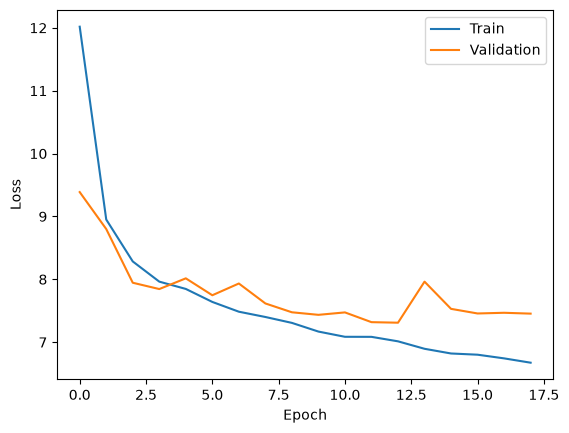

In [11]:
losses = torch.load(losses_path)

plt.plot(losses["train"], label="Train")
plt.plot(losses["val"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()